# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [57]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

In [58]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


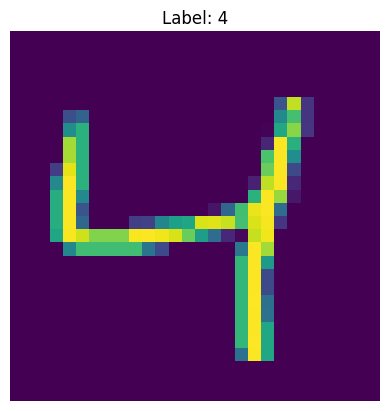

In [59]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [70]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [71]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: input_dim --> hidden_dim  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU(inplace=True)

        # Linear function 2: hidden_dim --> hidden_dim  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: hidden_dim --> hidden_dim  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU(inplace=True)

        # Linear function 4: hidden_dim --> output_dim  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    # forward 메소드 정의
    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1(out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2(out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3(out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [72]:
# ANN 객체 생성
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4): 5개

# model 객체 생성
model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [73]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)
        # --- forward 메소드를 따로 호출하지 않아도 됨 --- #
        # model에 input X를 넣자마자 forward가 실행되며, 이는 nn.Module에 이미 설정되어 있다.

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

Iteration: 500  Loss: 0.26579320430755615  Accuracy: 96.22494506835938 %
Iteration: 1000  Loss: 0.08200585097074509  Accuracy: 97.04222869873047 %
Iteration: 1500  Loss: 0.11746495962142944  Accuracy: 97.50924682617188 %
Iteration: 2000  Loss: 0.1940639764070511  Accuracy: 97.74275207519531 %
Iteration: 2500  Loss: 0.08531596511602402  Accuracy: 97.80113220214844 %
Iteration: 3000  Loss: 0.21844324469566345  Accuracy: 98.03463745117188 %
Iteration: 3500  Loss: 0.08773642033338547  Accuracy: 98.24868774414062 %
Iteration: 4000  Loss: 0.05248692259192467  Accuracy: 98.30706024169922 %
Iteration: 4500  Loss: 0.108013816177845  Accuracy: 98.42382049560547 %


#### **ANN 학습 결과**

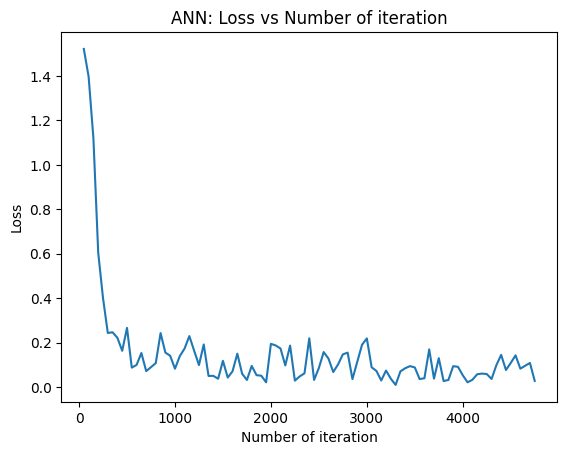

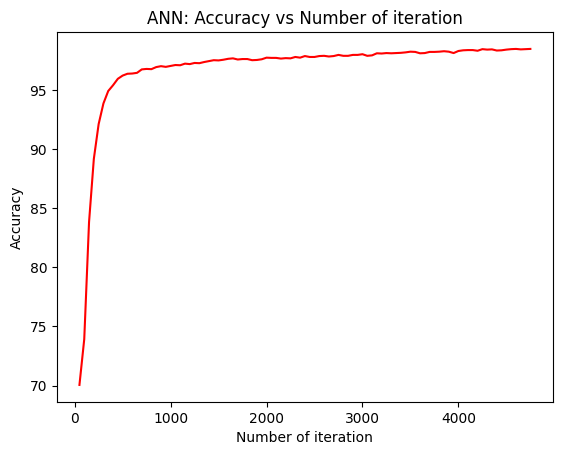

In [74]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
-
- **ANN: Loss vs Number of iteration**
  - iteration 수에 대한 loss 값을 보면, 초기에 대략 1.6 이상에서 시작하여 epoch이 진행될 때마다 빠르게 줄어들다가 0근처에서 안정되는 모습을 볼 수 있다.
  - 따라서 감소 패턴으로 보아 모델이 올바르게 데이터를 학습하고 있음을 의미한다.
  - 또, 약간의 노이즈가 있기는 하지만 loss가 발산하지 않고 감소하면서 수렴하는 형태를 띄고 있어 학습률(learning rate)도 적정값이라고 볼 수 있다.
  - 노이즈(출렁거림)가 있는 이유는 mini-batch SGD의 특성 때문이라 정상적인 현상이다. (batchsize = 64로 학습)

- **ANN: Accuracy vs Number of iteration**
  - 정확도 시각화 그래프도 살펴보면 학습이 진행될수록 정확도가 점점 상승하고 있기 때문에 마찬가지로 모델이 올바르게 학습하고 있다고 해석할 수 있다.
  - **최종 정확도가 약 98%로 높은 수준이다.**

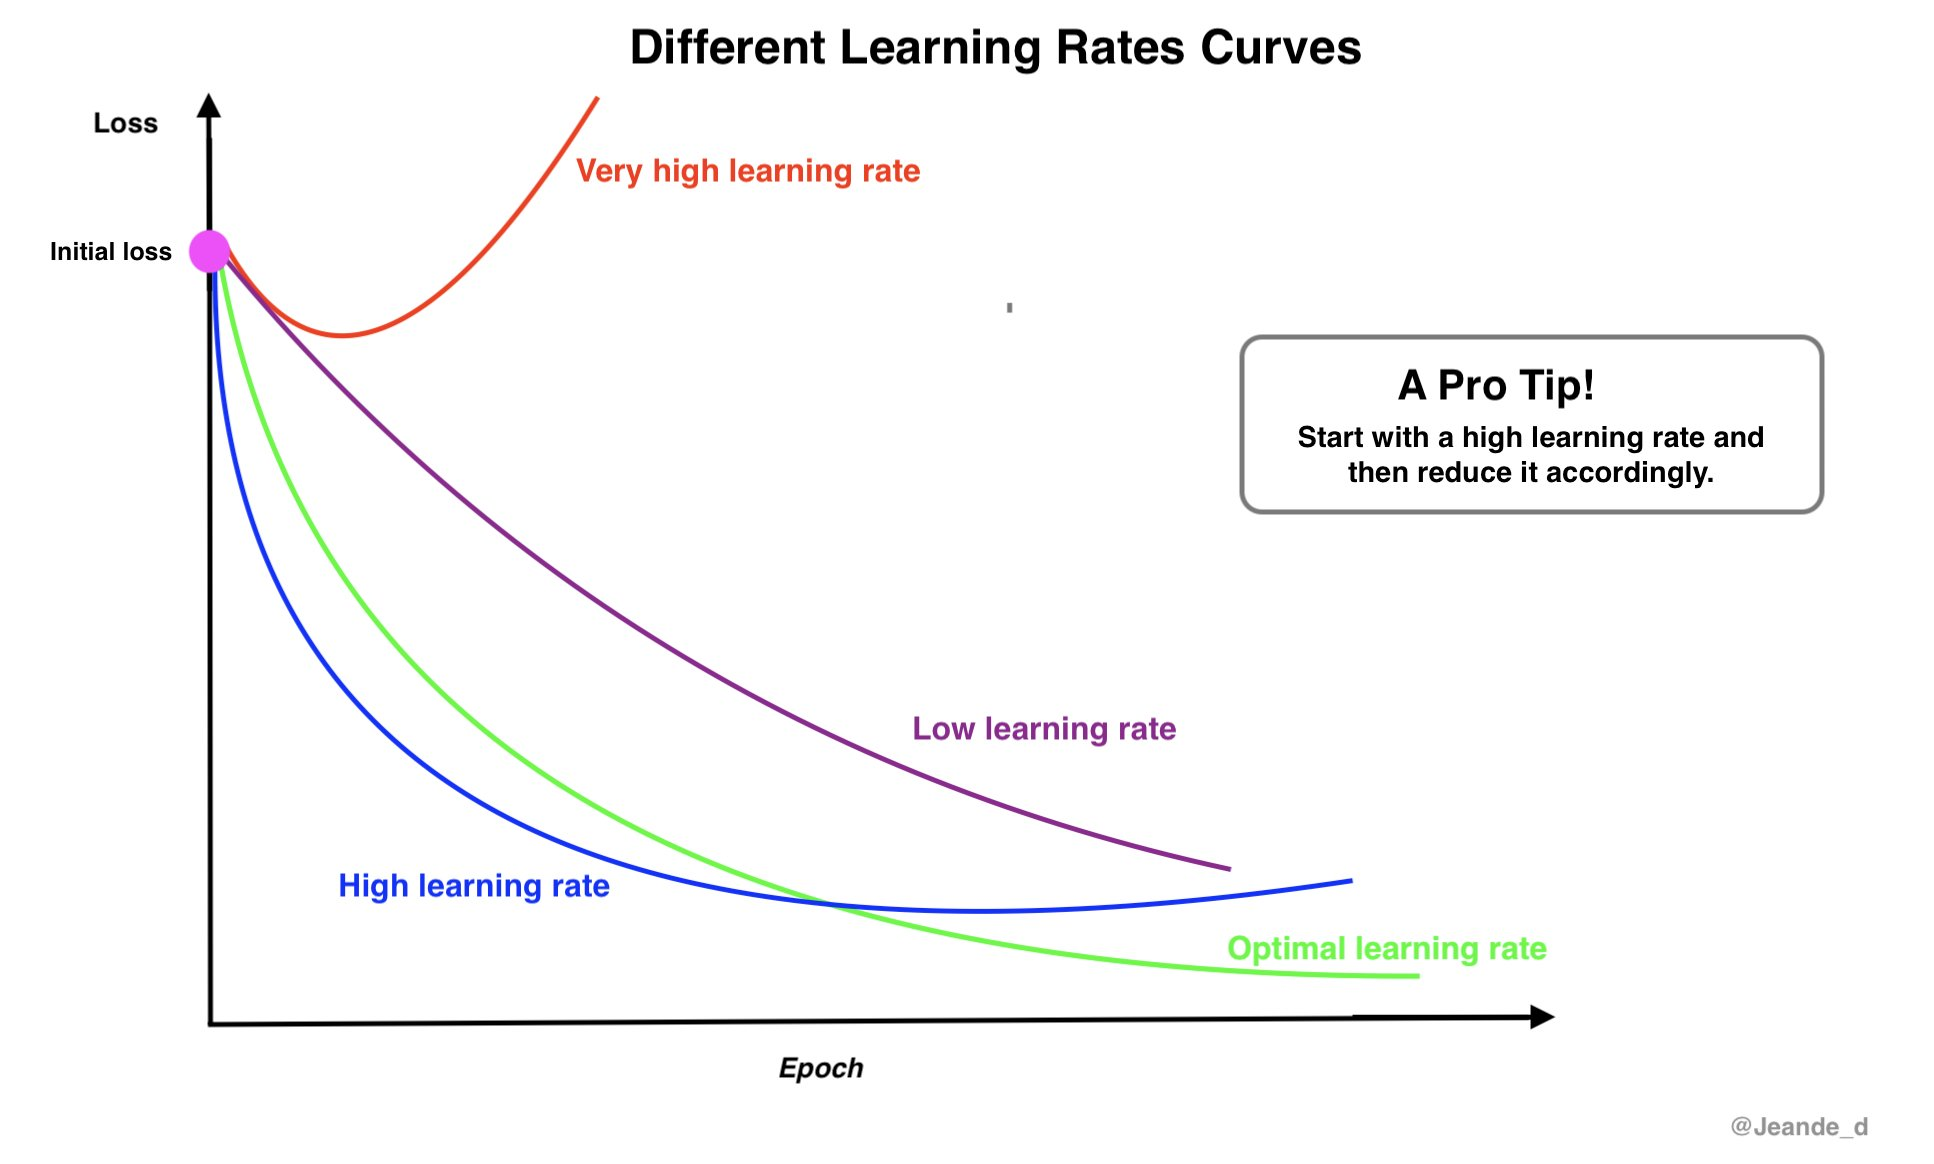

#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [77]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
input_dim = 28*28  # 이미지 크기 (28x28)
hidden_dims = [50, 100, 150, 200]  # 하이퍼파라미터
output_dim = 5  # 출력 클래스 개수 (0~4): 5개

In [78]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습

# 결과를 저장할 딕셔너리 초기화
results = {}

for hidden_dim in hidden_dims:
    print(f"Training hidden_dim: {hidden_dim}")
    # ANN 객체 생성
    model = ANNModel(input_dim,hidden_dim,output_dim)
    # 손실 함수 설정
    loss_ftn = nn.CrossEntropyLoss()

    # SGD Optimizer 사용
    learning_rate = 0.02
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # 학습을 모니터링하기 위한 변수들
    count = 0  # 반복 횟수
    loss_list = []  # hidden_dim의 Loss 저장 리스트
    iteration_list = []  #  hidden_dim의 Iteration 저장 리스트
    accuracy_list = []  # hidden_dim의 정확도 저장 리스트

    # 전체 학습
    for epoch in range(10):

        # 배치 단위 학습
        for i, (images, labels) in enumerate(train_loader):

            # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
            train = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
            labels = labels  # 텐서 형태 유지

            # 옵티마이저의 기울기 초기화
            optimizer.zero_grad()

            # Forward
            # 모델을 이용해 예측값(outputs) 계산
            outputs = model(train)
            # --- forward 메소드를 따로 호출하지 않아도 됨 --- #
            # model에 input X를 넣자마자 forward가 실행되며, 이는 nn.Module에 이미 설정되어 있다.

            # 손실 계산
            # cross entropy loss를 사용해 예측값과 실제값 비교
            loss = loss_ftn(outputs, labels)

            # Backward propagation - 손실에 대한 기울기 계산
            loss.backward()

            # 가중치 업데이트
            optimizer.step()

            count += 1  # 반복 횟수 증가

            if count % 50 == 0:
                # 정확도 계산을 위한 변수 초기화
                correct = 0
                total = 0


                # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
                for images, labels in test_loader:

                    test = images.view(-1, 784)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                    # Forward
                    # 예측값 계산
                    outputs = model(test)

                    # 예측값 중 가장 높은 값을 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 개수
                    total += len(labels)

                    # 올바르게 예측한 개수
                    correct += (predicted == labels).sum()

                # 정확도 계산
                accuracy = 100 * correct / float(total)

                # 손실 및 정확도 저장
                loss_list.append(loss.item())
                iteration_list.append(count)
                accuracy_list.append(accuracy)

                if count % 500 == 0:
                    # 손실 및 정확도 출력
                    print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

    # 현재 hidden_dim의 결과를 딕셔너리에 저장
    results[hidden_dim] = {
        'loss_list': loss_list,
        'iteration_list': iteration_list,
        'accuracy_list': accuracy_list
    }

Training hidden_dim: 50
Iteration: 500  Loss: 0.2798561155796051  Accuracy: 96.01089477539062 %
Iteration: 1000  Loss: 0.20022685825824738  Accuracy: 97.02276611328125 %
Iteration: 1500  Loss: 0.1324254721403122  Accuracy: 97.31465148925781 %
Iteration: 2000  Loss: 0.05106429010629654  Accuracy: 97.56761932373047 %
Iteration: 2500  Loss: 0.040879081934690475  Accuracy: 97.82058715820312 %
Iteration: 3000  Loss: 0.01796054281294346  Accuracy: 97.93733978271484 %
Iteration: 3500  Loss: 0.01652357168495655  Accuracy: 98.1903076171875 %
Iteration: 4000  Loss: 0.03559866547584534  Accuracy: 98.32652282714844 %
Iteration: 4500  Loss: 0.05858185142278671  Accuracy: 98.36544036865234 %
Training hidden_dim: 100
Iteration: 500  Loss: 0.08928094804286957  Accuracy: 96.380615234375 %
Iteration: 1000  Loss: 0.06325559318065643  Accuracy: 97.37303161621094 %
Iteration: 1500  Loss: 0.22600515186786652  Accuracy: 97.54816436767578 %
Iteration: 2000  Loss: 0.1276445984840393  Accuracy: 97.6065368652343

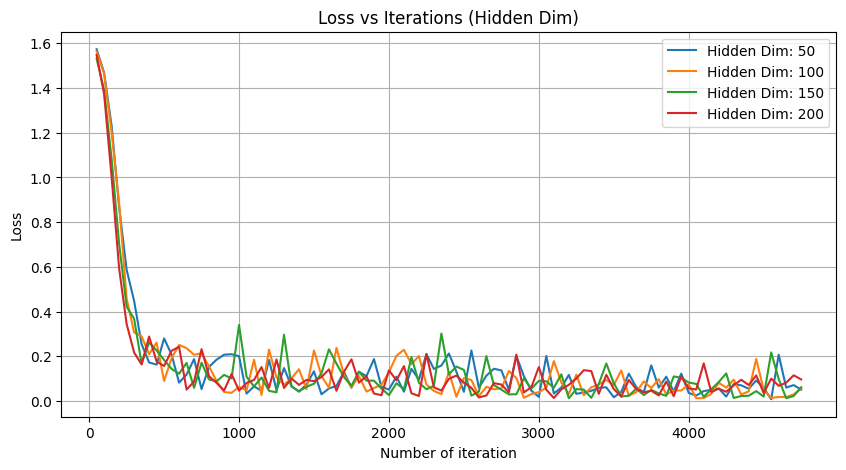

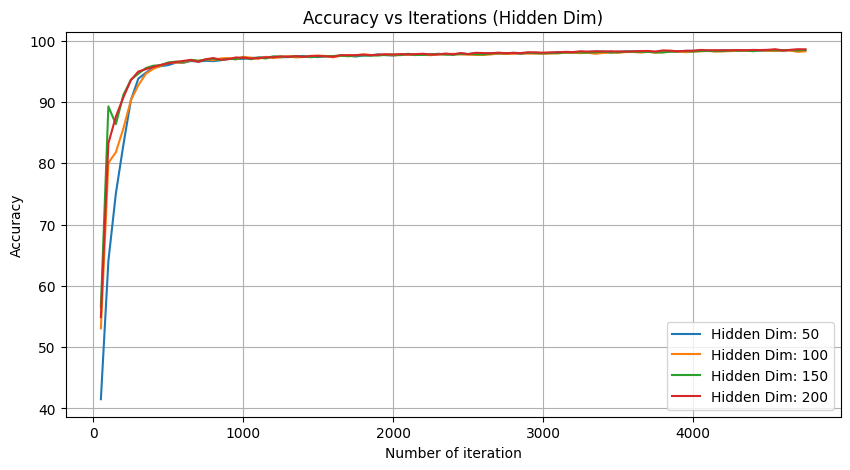

In [80]:
# 실험 1 모델 학습 결과 시각화

# loss 시각화
plt.figure(figsize=(10, 5))
for hidden_dim, data in results.items():
    plt.plot(data['iteration_list'], data['loss_list'], label=f'Hidden Dim: {hidden_dim}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Hidden Dim)")
plt.legend()
plt.grid(True)
plt.show()

# accuracy 시각화
plt.figure(figsize=(10, 5))
for hidden_dim, data in results.items():
    plt.plot(data['iteration_list'], data['accuracy_list'], label=f'Hidden Dim: {hidden_dim}')
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations (Hidden Dim)")
plt.legend()
plt.grid(True)
plt.show()

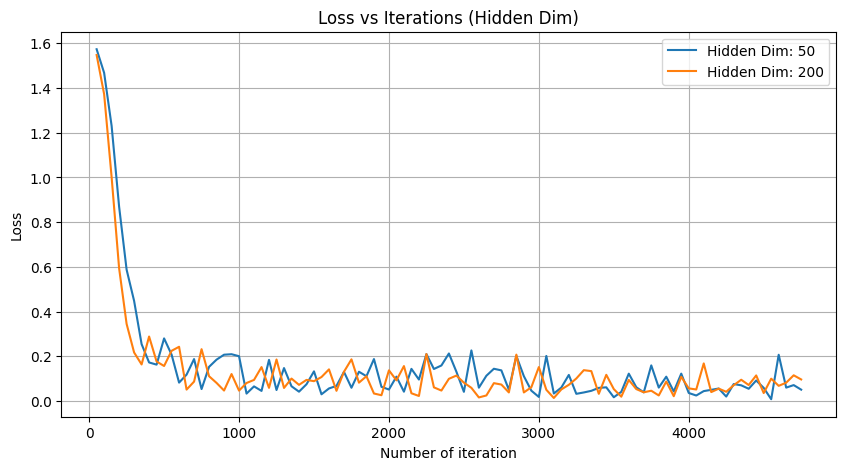

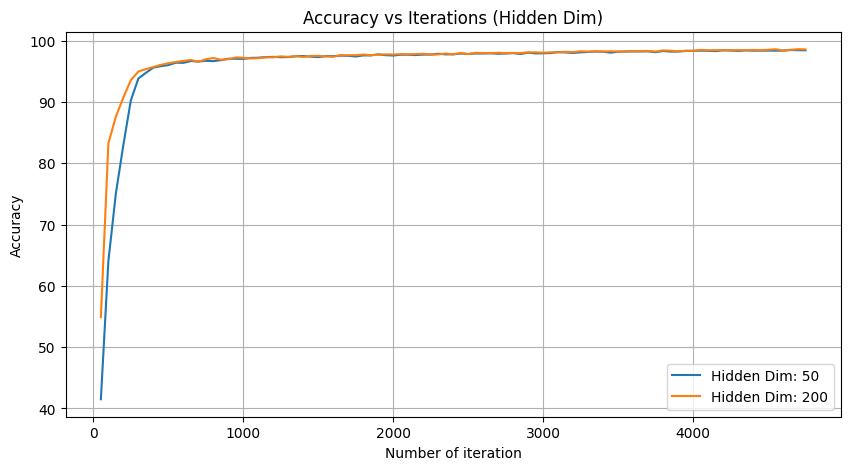

In [81]:
# 실험 1 모델 학습 결과 시각화 - hidden_dim 50과 200만 시각화

# 시각화할 hidden_dim 값
selected_hidden_dims = [50, 200]

# loss 시각화
plt.figure(figsize=(10, 5))
for hidden_dim, data in results.items():
    if hidden_dim in selected_hidden_dims:
        plt.plot(data['iteration_list'], data['loss_list'], label=f'Hidden Dim: {hidden_dim}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Hidden Dim)")
plt.legend()
plt.grid(True)
plt.show()

# accuracy 시각화
plt.figure(figsize=(10, 5))
for hidden_dim, data in results.items():
    if hidden_dim in selected_hidden_dims:
        plt.plot(data['iteration_list'], data['accuracy_list'], label=f'Hidden Dim: {hidden_dim}')
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations (Hidden Dim)")
plt.legend()
plt.grid(True)
plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- hidden dimension 값을 50, 100, 150, 200으로 나눠 비교를 수행하였다.

> loss vs iteration plot

- 우선 네 가지 모델 모두 loss를 살펴보면 대략 1.6에서 시작하여 빠르게 감소하는 것으로 보아 크기와 상관없이 모델이 데이터를 잘 학습하고 있다.
- hidden dimension 값 50과 200을 따로 분리하여 비교해보면, 50에 비해서 200이 loss 감소 속도가 더 빠르고 약간 더 매끄럽게 수렴하는 모습을 볼 수 있다.
- 하지만 두 모델 다 큰 차이는 없기 때문에 작은 네트워크(50)로도 충분히 학습 가능한 데이터셋이라고 해석할 수 있다.

> Accuracy vs iteration plot

- 네 가지 모델 모두 약 98%의 높은 정확도를 보인다.
- 50과 200만 따로 분리해 비교하자면, 50에 비해 200이 초기 정확도도 더 높고 더 빠르게 올라가는 것을 볼 수 있다.

In [82]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습

input_dim = 28*28
hidden_dim = 150 # hidden_dim은 고정
output_dim = 5
learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]

# 결과를 저장할 딕셔너리 초기화
lr_results = {}

for learning_rate in learning_rates:
    print(f"Training with learning_rate: {learning_rate}")
    # ANN 객체 생성
    model = ANNModel(input_dim,hidden_dim,output_dim)
    # 손실 함수 설정
    loss_ftn = nn.CrossEntropyLoss()

    # SGD Optimizer 사용 (learning_rate만 변경)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    # 학습을 모니터링하기 위한 변수들
    count = 0
    current_loss_list = []
    current_iteration_list = []
    current_accuracy_list = []

    # 전체 학습
    for epoch in range(5):

        # 배치 단위 학습
        for i, (images, labels) in enumerate(train_loader):

            train = images.view(-1, 784)
            labels = labels

            optimizer.zero_grad()

            outputs = model(train)
            loss = loss_ftn(outputs, labels)

            loss.backward()
            optimizer.step()

            count += 1

            if count % 50 == 0:
                correct = 0
                total = 0

                for images, labels in test_loader:

                    test = images.view(-1, 784)
                    outputs = model(test)
                    predicted = torch.max(outputs.data, 1)[1]

                    total += len(labels)
                    correct += (predicted == labels).sum()

                accuracy = 100 * correct / float(total)

                current_loss_list.append(loss.item())
                current_iteration_list.append(count)
                current_accuracy_list.append(accuracy)

                if count % 500 == 0:
                    print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))

    # 현재 learning_rate의 결과를 딕셔너리에 저장
    lr_results[learning_rate] = {
        'loss_list': current_loss_list,
        'iteration_list': current_iteration_list,
        'accuracy_list': current_accuracy_list
    }

Training with learning_rate: 0.1
Iteration: 500  Loss: 0.11347207427024841  Accuracy: 97.56761932373047 %
Iteration: 1000  Loss: 0.029446255415678024  Accuracy: 98.34598541259766 %
Iteration: 1500  Loss: 0.06580246984958649  Accuracy: 98.63787078857422 %
Iteration: 2000  Loss: 0.06999906152486801  Accuracy: 98.92975616455078 %
Training with learning_rate: 0.05
Iteration: 500  Loss: 0.02959655039012432  Accuracy: 97.45086669921875 %
Iteration: 1000  Loss: 0.1277301162481308  Accuracy: 97.97625732421875 %
Iteration: 1500  Loss: 0.09189600497484207  Accuracy: 98.1513900756836 %
Iteration: 2000  Loss: 0.0723554939031601  Accuracy: 98.54057312011719 %
Training with learning_rate: 0.02
Iteration: 500  Loss: 0.17328056693077087  Accuracy: 96.2444076538086 %
Iteration: 1000  Loss: 0.07912731915712357  Accuracy: 97.15898132324219 %
Iteration: 1500  Loss: 0.03914102911949158  Accuracy: 97.48978424072266 %
Iteration: 2000  Loss: 0.08254487812519073  Accuracy: 97.68437194824219 %
Training with lea

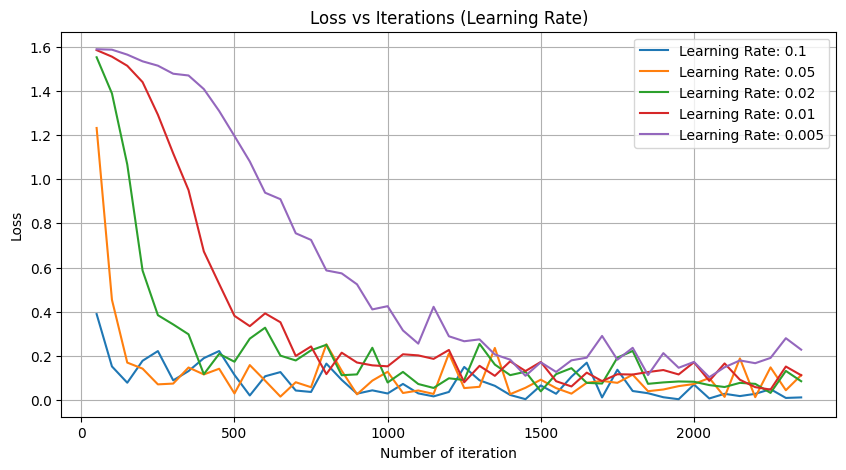

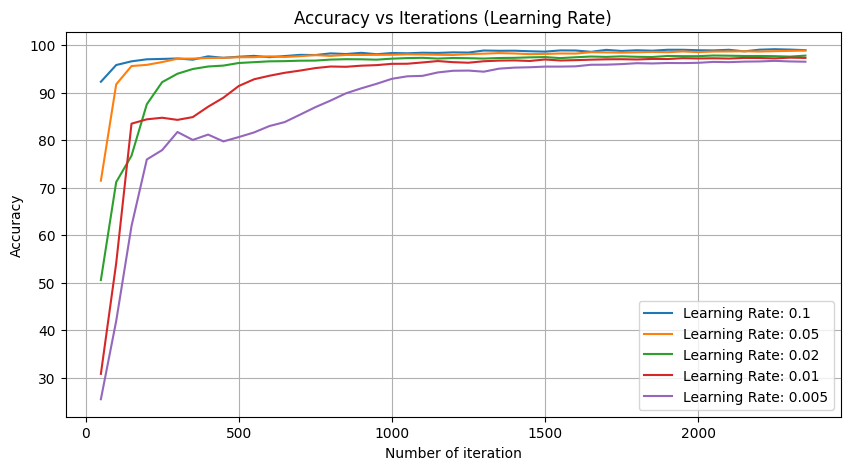

In [83]:
# 실험 2 모델 학습 결과 시각화

# loss 시각화
plt.figure(figsize=(10, 5))
for learning_rate, data in lr_results.items():
    plt.plot(data['iteration_list'], data['loss_list'], label=f'Learning Rate: {learning_rate}')
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("Loss vs Iterations (Learning Rate)")
plt.legend()
plt.grid(True)
plt.show()

# accuracy 시각화
plt.figure(figsize=(10, 5))
for learning_rate, data in lr_results.items():
    plt.plot(data['iteration_list'], data['accuracy_list'], label=f'Learning Rate: {learning_rate}')
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Iterations (Learning Rate)")
plt.legend()
plt.grid(True)
plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**
-
- learning rate를 0.1, 0.05, 0.02, 0.01, 0.005로 나눠서 비교를 수행하였다.
> loss vs iterations plot
- 학습률 0.1이 가장 초기 loss도 낮고, 매우 짧은 iteration 내에 0에 가깝게 수렴하였다.
- 학습률 0.05도 빠르게 loss가 줄어들었으며, 0.1보다 약간 느리지만 안정적으로 수렴하였다.
- 학습률 0.02, 0.01은 loss가 줄어드는 속도가 눈에 띄게 느렸지만, 충분히 많은 iteration이 지나면 안정적으로 수렴하였다.
- 반면, 학습률 0.005의 경우 매우 느리게 줄어들며 iteration 2000이 넘어가도 loss가 충분히 줄어들지 않았다.
- 학습률이 줄어들수록 loss가 줄어드는 속도가 느리지만 반대로 안정적으로 줄어들며 0에 가깝게 수렴하는 모습을 볼 수 있다.

> accuracy vs iterations plot
- 학습률 0.1이 초기 정확도도 높고 최종적으 98%에 근접하게 나타났다.
- 학습률 0.05 역시 높은 정확도로 수렴하며, 안정적인 학습을 보여주었다.
- 학습률이 낮아질수록 (0.02, 0.01, 0.005) 정확도 상승 속도가 느려지고, 일정 iteration까지는 성능이 낮게 유지되었다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [85]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32*4*4, 10)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [86]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.001)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [87]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 2.0822260227979847
Epoch 2, Loss: 1.458203288607906
Epoch 3, Loss: 0.8194026689439825
Epoch 4, Loss: 0.36635418133596287
Epoch 5, Loss: 0.23890106107782969
Epoch 6, Loss: 0.19354088854876839
Epoch 7, Loss: 0.1718878234913553
Epoch 8, Loss: 0.1593233545258299
Epoch 9, Loss: 0.15059167871908877
Epoch 10, Loss: 0.1442340386249825
Epoch 11, Loss: 0.1393390754879392
Epoch 12, Loss: 0.1352641586222081
Epoch 13, Loss: 0.13156538030486514
Epoch 14, Loss: 0.12819793756291978
Epoch 15, Loss: 0.12553963631329307
Epoch 16, Loss: 0.12258547786351037
Epoch 17, Loss: 0.12061200842712394
Epoch 18, Loss: 0.11794613147376101
Epoch 19, Loss: 0.11559727901324536
Epoch 20, Loss: 0.11339528285869103


In [89]:
# CNN 모델 최종 정확도 계산 및 출력

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        predicted = torch.max(outputs.data, 1)[1]
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / float(total)
print(f'Final Test Accuracy of the CNN model: {accuracy} %')

Final Test Accuracy of the CNN model: 97.43140688849971 %


#### **CNN 학습 결과**

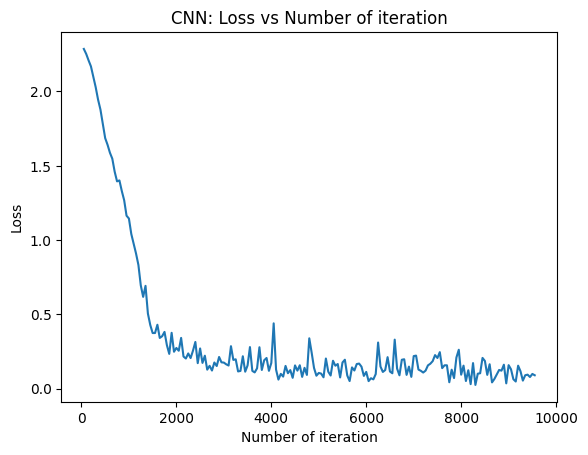

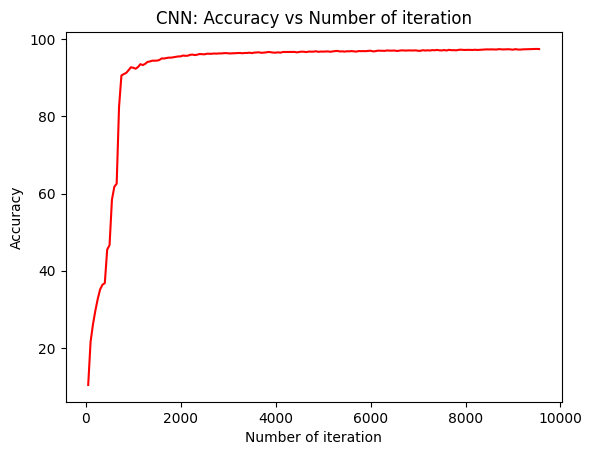

In [88]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
-
> ANN
- 구조: 입력층(Input) → 은닉층(Hidden Layer, Fully Connected) → 출력층(Output)
- 특징
  - 이미지(28×28=784 픽셀)를 1차원 벡터로 펼쳐서 사용
  - 모든 픽셀이 서로 연결되므로, 공간적 정보(위치, 패턴)가 손실됨.
  - 학습과정에서 파라미터 최적값 찾기 어려움.

> CNN
- 구조: 합성곱 계층(Conv Layer) + 활성화 함수(ReLU) + 풀링(Pooling) → Fully Connected → 출력층
- 특징
  - 합성곱 계층의 각 뉴런은 입력 이미지의 작은 영역에만 연결되어 있어 네트워크가 공간적 계층 구조와 특징(예: 모서리, 패턴, 곡선)을 효과적으로 학습할 수 있음.
  - 이미지, 영상, 음성 등 공간적 구조가 있는 데이터에 특히 강력
  - 계층이 깊어질수록 저수준 특징 → 고수준 특징을 학습함.

---
## [학습 결과 비교]
> loss
- ANN: 대략 0.2 수준까지 줄어드는 양상을 보임.
- CNN: epoch 6에서 이미 0.2 이하로 줄어들었으며, epoch 20에서 최종적으로 0.1에 가깝게 줄어든 모습을 보임.

> accuracy
- ANN과 CNN 모두 약 97~98% 정도의 정확도를 보이며 큰 차이가 없음.